In [1]:
import pandas as pd
import os
from arima.utils.utils import EnsembleProjections
from ndc_probability.utils.prob_utils import ProbUtils
from scenario_discovery.utils.utils import ScenarioDiscoveryOptimizer, VulnerabilityAnalyzer

In [2]:
ep = EnsembleProjections()
pu = ProbUtils()
sdo = ScenarioDiscoveryOptimizer()
va = VulnerabilityAnalyzer()

In [3]:
# Set up run id
RUN_ID = 1773188058
SD_OUTPUT_ID = "1773188058_124_20260408_145246"

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
FIGURES_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "paper_figures")
os.makedirs(FIGURES_DIR_PATH, exist_ok=True)

ARIMA_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "arima")
ARIMA_ENSEMBLE_DIR_PATH = os.path.join(ARIMA_DIR_PATH, "output", "ensemble")
ARIMA_POSTPROCESSING_DIR_PATH = os.path.join(ARIMA_DIR_PATH, "output", "postprocessed_ensemble")
HP_FILTERED_DIR_PATH = os.path.join(ARIMA_DIR_PATH, "output", "hp_filtered")

ML_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "ml")
ML_TRAINING_DIR_PATH = os.path.join(ML_DIR_PATH, "output", "training")

PROB_TABLES_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "ndc_probability", "tables")
SD_OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "scenario_discovery", "output", SD_OUTPUT_ID)

In [5]:
historical_df = pd.read_csv(os.path.join(ML_TRAINING_DIR_PATH, f"training_df_{RUN_ID}.csv"))
historical_df.head()

,iso_alpha_3,year,x_log_signed_con_edgar_ghg_mt,x_log_signed_con_solar,inc_has_efficiency_standard,inc_has_renewable_target,con_net_elec_imports_twh,x_log_signed_cap_civil_liberties_idx,inc_has_carbon_tax,inc_has_ets,...,x_log_signed_con_gas,x_log_signed_con_demand_per_capita,cap_regulatory_quality,cap_rule_of_law,cap_govt_effectiveness,con_ndgain_score,em_trend_3y,em_trend_5y,em_acceleration,em_volatility_5y
0,AFG,2005,2.954458,0.0,0.0,0.0,0.10,0.433080,0.0,0.0,...,0.0,0.039221,-1.643440,-1.662966,-1.228816,32.098198,0.020222,0.020222,0.000000,0.022522
1,AFG,2006,2.968414,0.0,0.0,0.0,0.43,0.431782,0.0,0.0,...,0.0,0.048790,-1.689469,-1.879005,-1.473652,30.590486,0.012104,0.018786,-0.006682,0.025614
2,AFG,2007,3.026143,0.0,0.0,0.0,0.61,0.433080,0.0,0.0,...,0.0,0.058269,-1.708872,-1.852560,-1.440111,30.163952,0.017559,0.017533,0.000026,0.028694
3,AFG,2008,3.181789,0.0,0.0,0.0,0.75,0.433080,0.0,0.0,...,0.0,0.058269,-1.607167,-1.903308,-1.527795,29.877764,0.035842,0.022690,0.013152,0.038868
4,AFG,2009,3.307380,0.0,0.0,0.0,1.15,0.435024,0.0,0.0,...,0.0,0.067659,-1.664508,-1.876119,-1.507752,30.253636,0.106687,0.056867,0.049820,0.100536


In [6]:
historical_em_df = pd.read_parquet(os.path.join(HP_FILTERED_DIR_PATH, f"historical_emissions_hp_trend_{RUN_ID}.parquet"))
historical_em_df.head()

,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,AFG,2005,17.028758
1,AFG,2006,19.322808
2,AFG,2007,21.713737
3,AFG,2008,24.226614
4,AFG,2009,26.711821


## Arima Projection Figures

### Predictors Projections

In [7]:
raw_ensemble_df = pd.read_parquet(os.path.join(ARIMA_ENSEMBLE_DIR_PATH, f"ensemble_arima_{RUN_ID}.parquet"))
raw_ensemble_df.head()

,iso_alpha_3,future_id,year,x_log_signed_con_edgar_ghg_mt,x_log_signed_con_solar,inc_has_efficiency_standard,inc_has_renewable_target,con_net_elec_imports_twh,x_log_signed_cap_civil_liberties_idx,inc_has_carbon_tax,...,cap_govt_effectiveness,con_ndgain_score,emissions_anchor_2022,years_since_2022,trend_year_interaction,em_lag_1y,em_trend_3y,em_trend_5y,em_volatility_5y,em_acceleration
0,AFG,id_AFG_1,2022,3.405119,0.048790,0.0,0.0,5.880000,0.040182,0.0,...,-1.880035,32.633596,NaN,0.0,NaN,3.399653,-0.022348,-0.028681,0.050438,0.006334
1,AFG,id_AFG_1,2023,3.406011,0.055667,0.0,0.0,6.009763,0.000000,0.0,...,-2.028122,32.452377,NaN,1.0,NaN,3.400199,-0.018481,-0.027746,0.049581,0.006627
2,AFG,id_AFG_1,2024,3.395691,0.063294,0.0,0.0,6.157955,0.000000,0.0,...,-2.189786,33.519214,NaN,2.0,NaN,3.400289,-0.019795,-0.026254,0.047960,0.006346
3,AFG,id_AFG_1,2025,3.384084,0.070110,0.0,0.0,6.515455,0.000000,0.0,...,-2.319343,33.014896,NaN,3.0,NaN,3.399257,-0.020584,-0.025285,0.046763,0.006171
4,AFG,id_AFG_1,2026,3.391456,0.071661,0.0,0.0,6.538660,0.000000,0.0,...,-2.482714,34.419108,NaN,4.0,NaN,3.398096,-0.021209,-0.026219,0.046283,0.006201


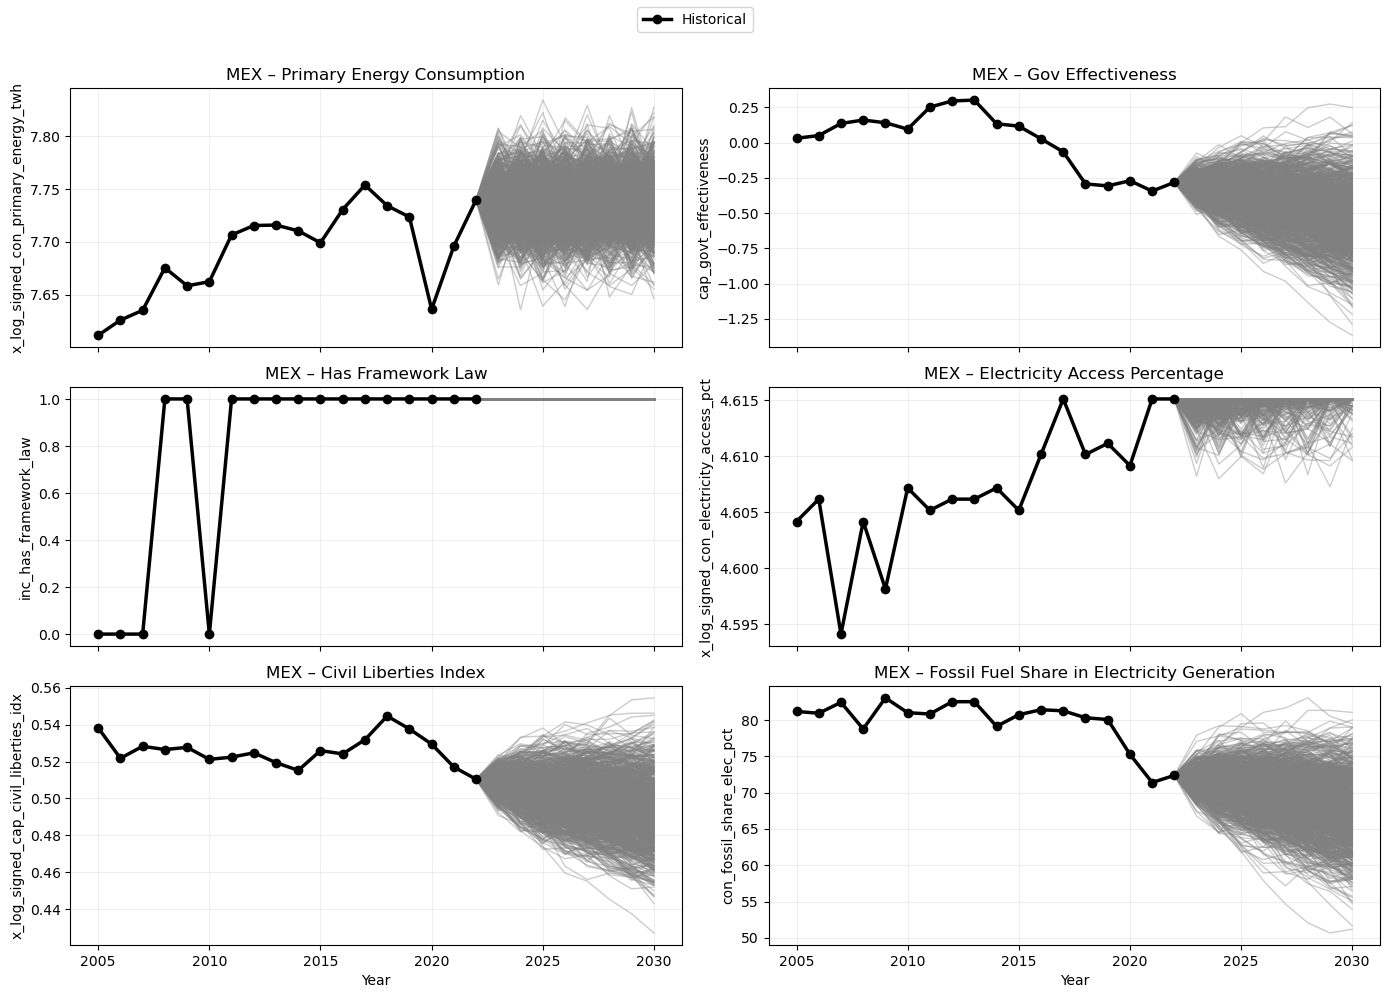

In [8]:
iso = "MEX"

columns = {
    "x_log_signed_con_primary_energy_twh": "Primary Energy Consumption",
    "cap_govt_effectiveness": "Gov Effectiveness",
    "inc_has_framework_law": "Has Framework Law",
    "x_log_signed_con_electricity_access_pct": "Electricity Access Percentage",
    "x_log_signed_cap_civil_liberties_idx": "Civil Liberties Index",
    "con_fossil_share_elec_pct": "Fossil Fuel Share in Electricity Generation",
}

panels = [
    {"iso": iso, "column": col, "title": f"{iso} – {label}"}
    for col, label in columns.items()
]

ep.plot_ensemble_time_series_grid(
    df=raw_ensemble_df,
    hist_df=historical_df,
    panels=panels,
    ncols=2,
    figsize=(14, 10),
    save_path=os.path.join(FIGURES_DIR_PATH, f"raw_ensemble_{iso.lower()}_drivers.png"),
)

### Emission Predictions

In [9]:
postprocessed_ensemble_df = pd.read_parquet(os.path.join(ARIMA_POSTPROCESSING_DIR_PATH, f"postprocessed_ensemble_{RUN_ID}.parquet"))
postprocessed_ensemble_df.head()

,future_id,iso_alpha_3,year,con_edgar_ghg_mt_hp_trend
0,id_AFG_10,AFG,2022,28.630028
1,id_AFG_10,AFG,2023,29.511985
2,id_AFG_10,AFG,2024,30.435955
3,id_AFG_10,AFG,2025,31.448054
4,id_AFG_10,AFG,2026,32.404918


In [10]:
ndc_prob_df = pd.read_csv(os.path.join(PROB_TABLES_DIR_PATH, f"ndc_probability_analysis_{RUN_ID}.csv"))
ndc_prob_df.head()

,iso_alpha_3,n_futures,meets_ndc_unconditional_target,meets_ndc_conditional_target,Country,2020_edgar_ghg_mt,unconditional_target,conditional_target,2030_q1_mean_value
0,AFG,949,0.416228,0.321391,Afghanistan,28.150674,42.419422,37.332373,24.367323
1,ALB,991,1.000000,1.000000,Albania,7.863104,11.297782,11.297782,0.599486
2,ARG,998,0.006012,0.006012,Argentina,359.025664,320.592031,320.592031,364.270168
3,ARM,992,0.563508,1.000000,Armenia,9.802551,10.300642,14.673556,8.637496
4,AUT,992,0.000000,0.000000,Austria,78.305917,30.071405,30.071405,70.130155


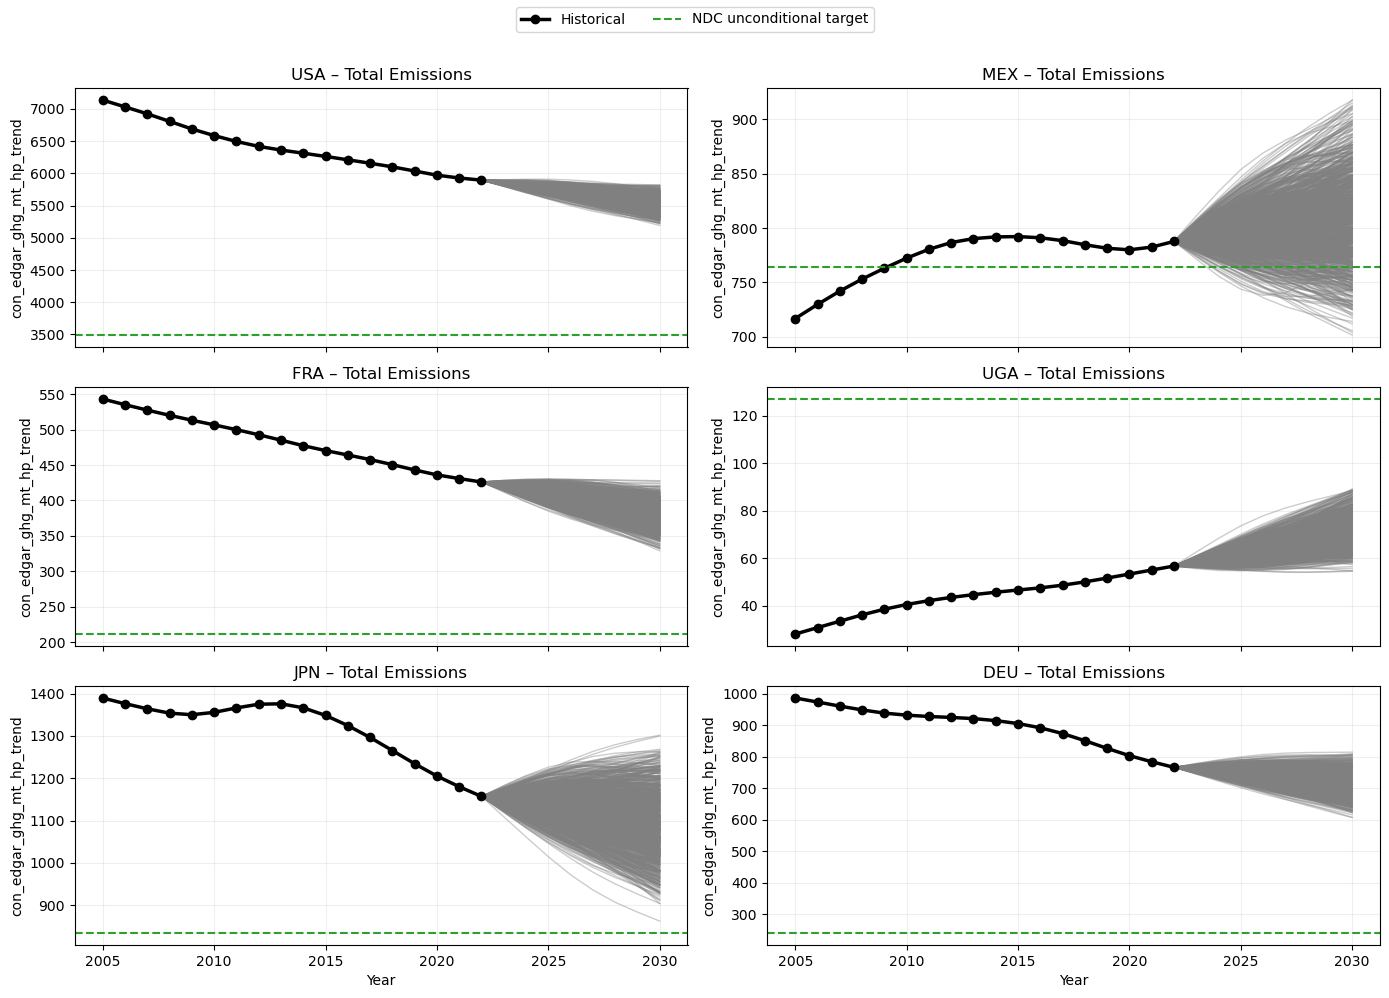

In [11]:
emissions_variable = "con_edgar_ghg_mt_hp_trend"

panels = [
    {"iso": "USA", "column": emissions_variable, "title": "USA – Total Emissions"},
    {"iso": "MEX", "column": emissions_variable, "title": "MEX – Total Emissions"},
    {"iso": "FRA", "column": emissions_variable, "title": "FRA – Total Emissions"},
    {"iso": "UGA", "column": emissions_variable, "title": "UGA – Total Emissions"},
    {"iso": "JPN", "column": emissions_variable, "title": "JPN – Total Emissions"},
    {"iso": "DEU", "column": emissions_variable, "title": "DEU – Total Emissions"},
]

ep.plot_ensemble_time_series_grid(
    df=postprocessed_ensemble_df,
    hist_df=historical_em_df,
    ndc_targets_df=ndc_prob_df,
    ndc_target_display="unconditional",
    panels=panels,
    ncols=2,
    figsize=(14, 10),
    save_path=os.path.join(FIGURES_DIR_PATH, "postprocessed_ensemble_total_emissions_ndc.png")
)

## Probability Analysis

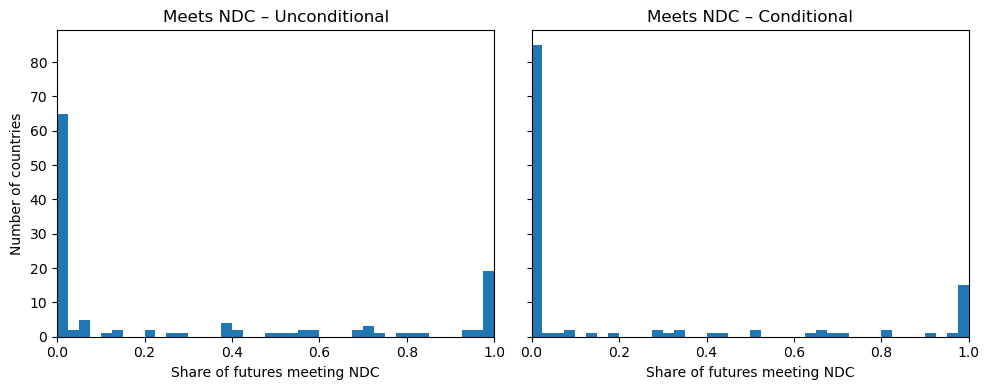

In [12]:
pu.plot_ndc_meets_histograms(
    df=ndc_prob_df,
    bins=40,
    save_path=os.path.join(FIGURES_DIR_PATH, "ndc_meets_histograms.png")
)

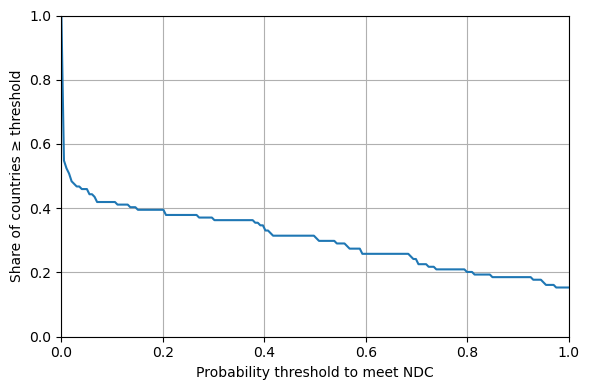

In [13]:
pu.plot_share_countries_above_probability(
    ndc_prob_df,
    prob_col="meets_ndc_unconditional_target",
    save_path=os.path.join(FIGURES_DIR_PATH, "share_countries_above_unconditional_probability.png")
)

In [14]:
total_countries = ndc_prob_df['iso_alpha_3'].nunique()
total_countries_with_prob = ndc_prob_df[ndc_prob_df['meets_ndc_unconditional_target'] > 0.5]['iso_alpha_3'].nunique()

print(f"Number of countries in the analysis: {total_countries}")
print(f"Percentage of countries having > 50% probability of meeting the unconditional target: {(total_countries_with_prob / total_countries * 100):.2f}%")

Number of countries in the analysis: 124
Percentage of countries having > 50% probability of meeting the unconditional target: 30.65%


## Scenario Discovery

In [15]:
regions_of_interest = ["JPN", "MOZ", "MEX"]
opt_results_df_dict = {}
future_dist_df_dict = {}

for region in regions_of_interest:
    opt_results_df_dict[region] = {}
    opt_results_df = pd.read_csv(os.path.join(SD_OUTPUT_DIR_PATH, f"{region}", f"{region}_optimization_results.csv"))
    opt_table_input_df = pd.read_csv(os.path.join(SD_OUTPUT_DIR_PATH, f"{region}", f"{region}_optimization_input_table.csv"))
    opt_results_df_dict[region]["opt_result"] = opt_results_df
    opt_results_df_dict[region]["opt_table_input"] = opt_table_input_df

    future_dist_df = pd.read_csv(os.path.join(SD_OUTPUT_DIR_PATH, f"{region}", f"{region}_future_distribution_input_table.csv"))
    future_dist_df_dict[region] = future_dist_df

### 2030 Emission Distribution

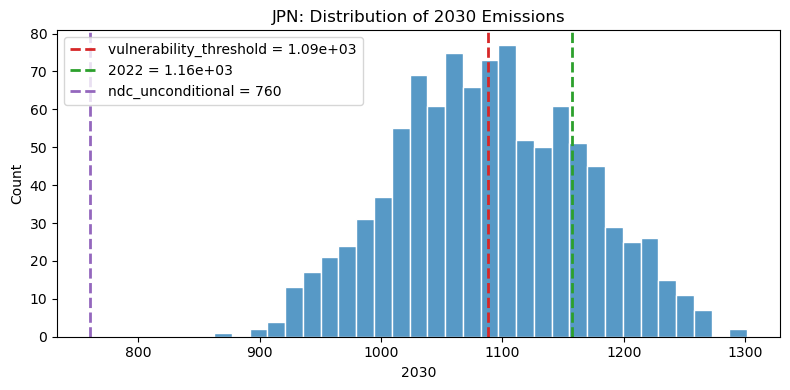

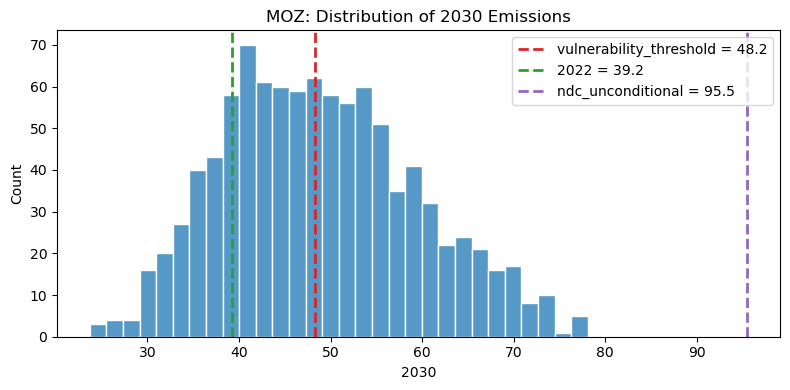

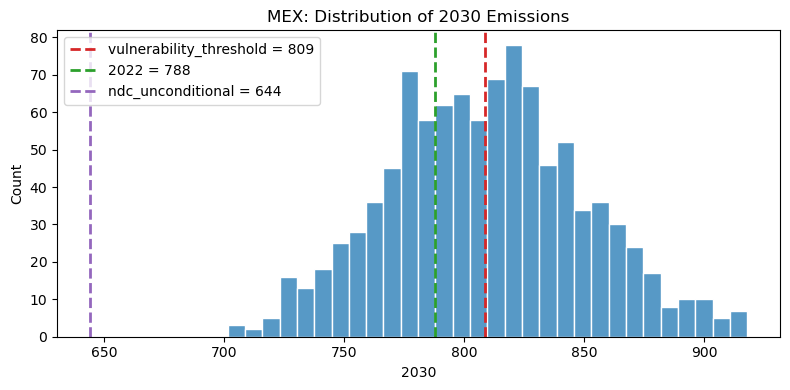

In [16]:
for region, future_dist_df in future_dist_df_dict.items():
    va.plot_future_distribution_with_baseline(
        df_pivot=future_dist_df,
        future_col="2030",
        baseline_col="vulnerability_threshold",
        title=f"{region}: Distribution of 2030 Emissions",
        save_path=os.path.join(FIGURES_DIR_PATH, f"{region.lower()}_distribution_2030_emissions.png")
    )

### Pareto Front

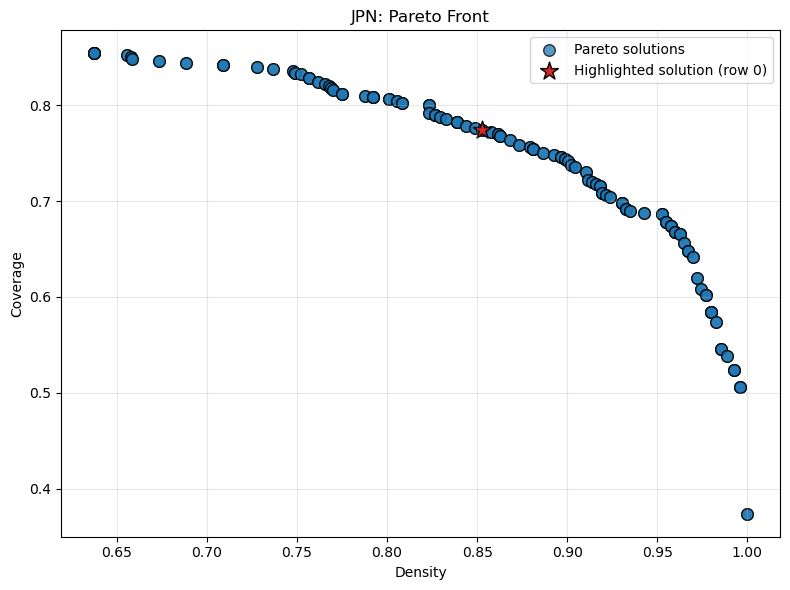

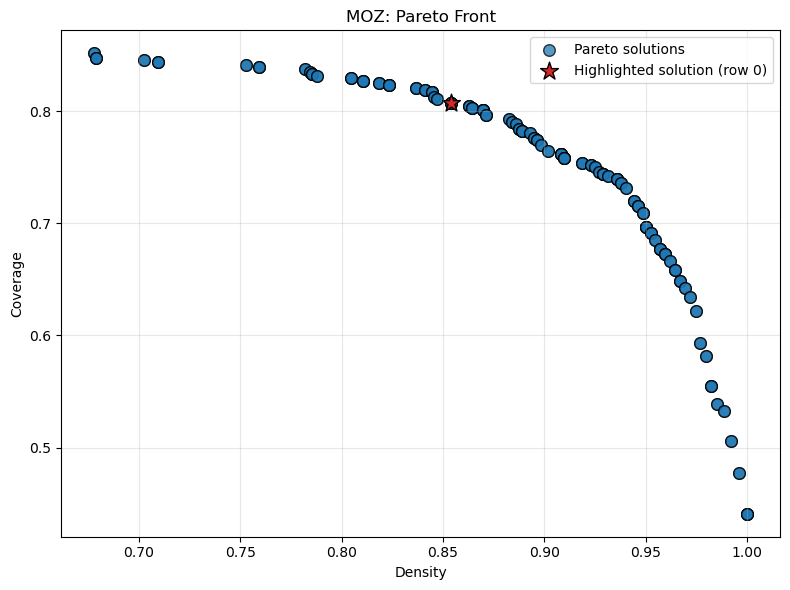

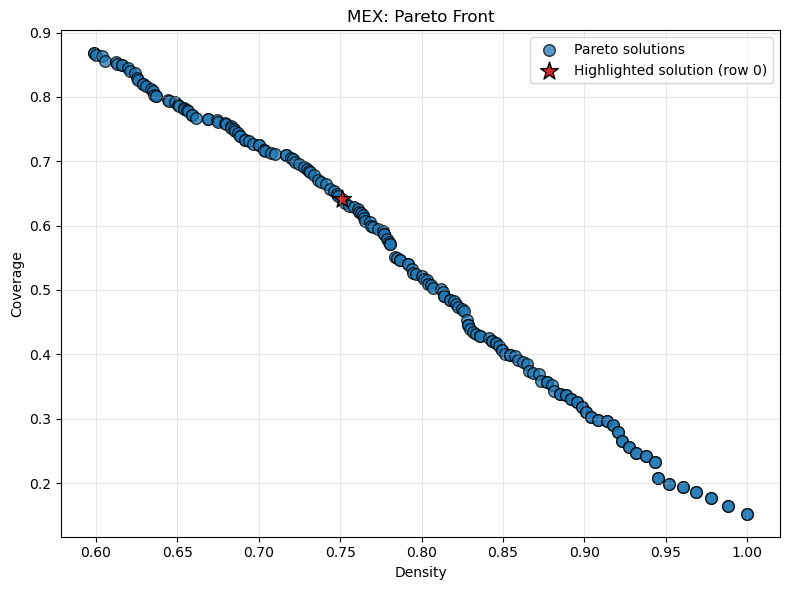

In [17]:
for region, opt_results_df in opt_results_df_dict.items():
    sdo.plot_pareto_front(
        opt_results_df["opt_result"],
        annotate=False,
        title=f"{region}: Pareto Front",
        save_path=os.path.join(FIGURES_DIR_PATH, f"{region.lower()}_pareto_front.png")
    )

### Optimized Boxes

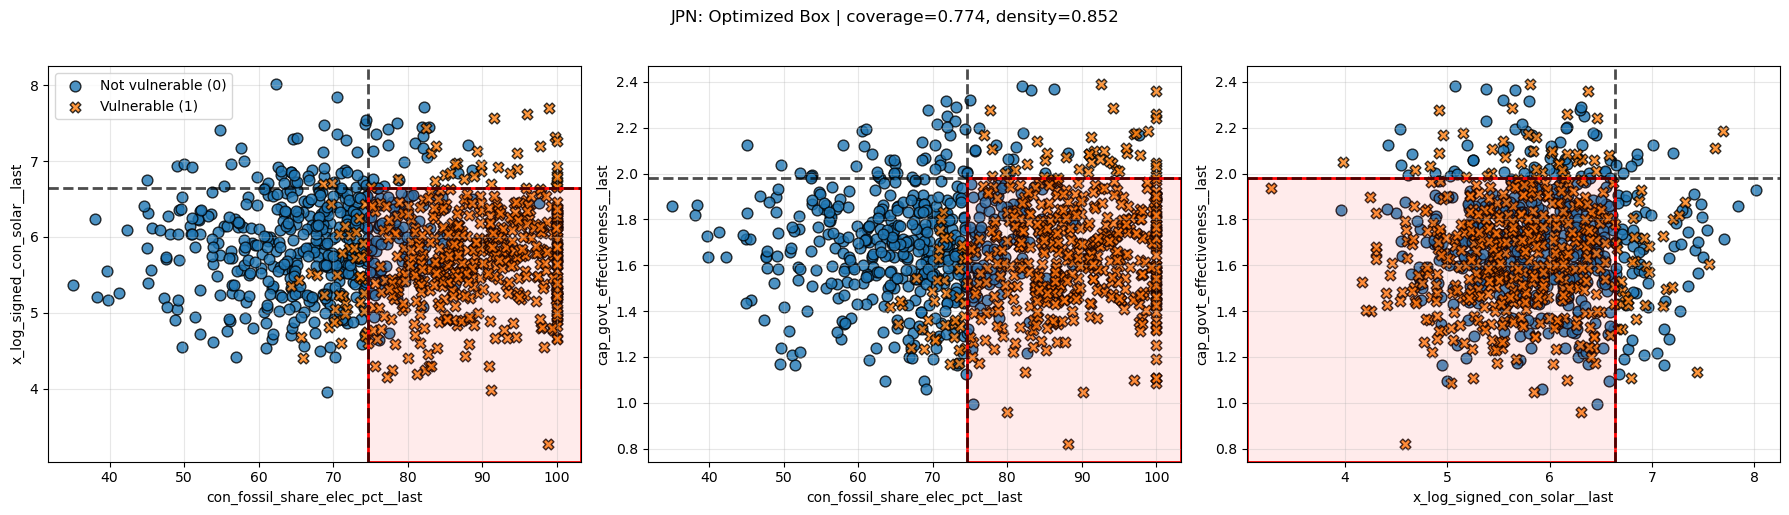

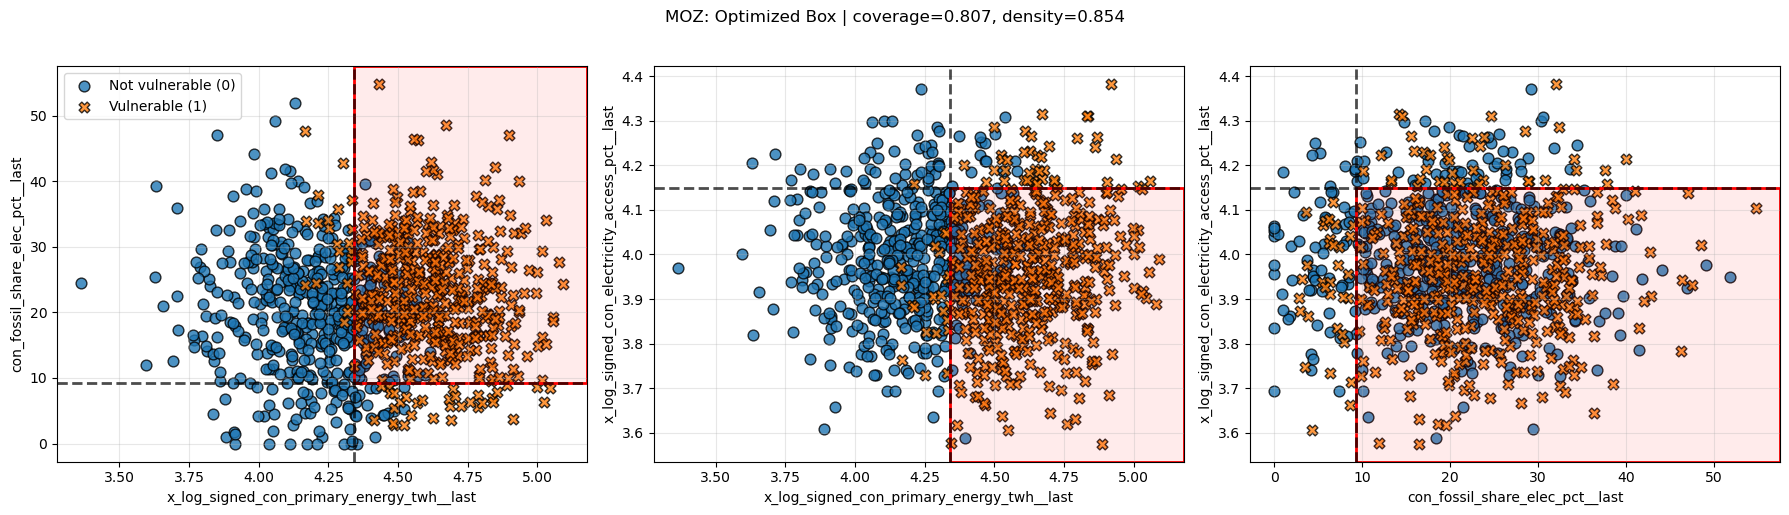

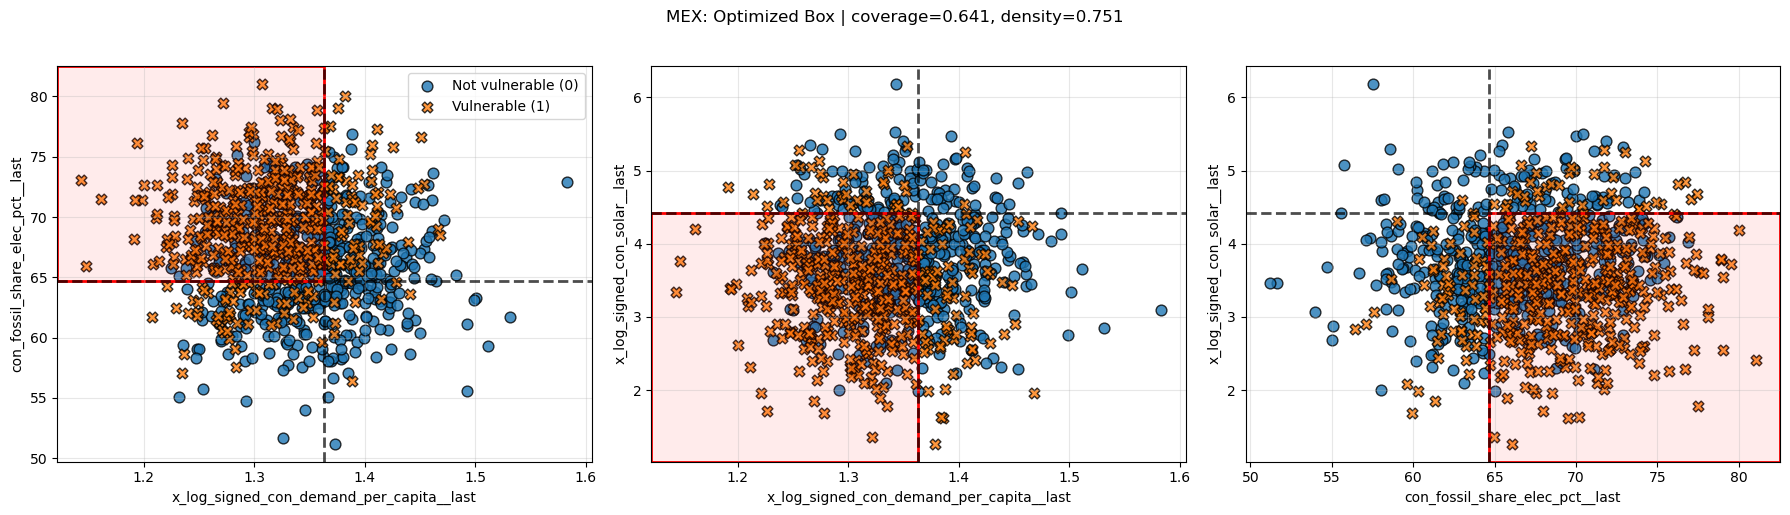

In [18]:
for region, opt_results_df in opt_results_df_dict.items():
    result_row = opt_results_df["opt_result"].iloc[0]

    sdo.plot_boxed_scatter_from_optimization_result(
        opt_results_df["opt_table_input"],
        opt_results_df["opt_result"],
        row_idx=0,
        title=(
            f"{region}: Optimized Box | "
            f"coverage={result_row['coverage']:.3f}, "
            f"density={result_row['density']:.3f}"
        ),
        save_path=os.path.join(FIGURES_DIR_PATH, f"{region.lower()}_optimized_box.png"),
    )


### Top driver combinations

In [19]:
top_combinations_df = pd.read_csv(os.path.join(SD_OUTPUT_DIR_PATH, f"{SD_OUTPUT_ID}_top_variable_combination_frequency_report.csv"))
top_combinations_df.head()

,feature_combination,count,high_income_countries,low_income_countries,lower_middle_income_countries,upper_middle_income_countries,unclassified_countries
0,con_fossil_share_elec_pct|con_renewables_share...,30,AUT|CRI|GRC|HUN|IRL|LTU|LUX|NZL|SYC,BFA|MLI|RWA|SLE,BOL|CIV|CMR|GHA|HND|HTI|JOR|KHM|MRT|NGA|SEN|ZMB,AZE|CPV|ECU|GTM|SUR,NaN
1,con_fossil_share_elec_pct|x_log_signed_con_dem...,8,CYP|HRV,NaN,STP,ARM|GAB|GNQ|PER|UKR,NaN
2,x_log_signed_cap_civil_liberties_idx|x_log_sig...,8,SVN,NaN,COM|KGZ|TUN|UZB,LBY|MDV|TUR,NaN
3,cap_govt_effectiveness|con_fossil_share_elec_p...,7,PAN|SVK,NaN,MMR|NIC|TJK,ARG|SLV,NaN
4,cap_govt_effectiveness|x_log_signed_con_demand...,5,ISL|KWT,NaN,NaN,DZA|FJI|GEO,NaN


In [20]:
max_count = top_combinations_df['count'].max()
top_rows = top_combinations_df[top_combinations_df['count'] == max_count]

print("Top driver combination(s) and count:")
for _, row in top_rows.iterrows():
    print(f"{row['feature_combination']} — {int(row['count'])}")

Top driver combination(s) and count:
con_fossil_share_elec_pct|con_renewables_share_elec_pct|x_log_signed_con_primary_energy_twh — 30
